In [15]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import cv2 as cv
from pathlib import Path 
from tqdm import tqdm

In [2]:
def calc_soi_lags(canvas, frame_shape, high_frame_threshold, low_frame_threshold, df, thickness, lag):

    canvas_threshold = np.zeros(frame_shape, dtype=np.uint16)
    tracks2draw = df.loc[(df['frame']<high_frame_threshold)&
                              (df['frame']>=low_frame_threshold),
                              'track_id'].unique()
    l2_len = 0
    for tr in tracks2draw:
        # get track points
        pts = df.loc[(df['frame']<high_frame_threshold)&
                          (df['frame']>=low_frame_threshold)&
                          (df['track_id']==tr),
                          ['x', 'y']].to_numpy(dtype=np.int32)
        # calc track l2 length
        increments = np.diff(pts, axis=0)
        l2_len += np.linalg.norm(increments, axis=1).sum()

        # draw track
        buffer = np.zeros(frame_shape, dtype=np.uint8)
        cv.polylines(
            buffer,
            [pts],
            isClosed=False,
            color=1,
            thickness=thickness
        )
        
        canvas_threshold += buffer
        
    canvas += canvas_threshold
    union_mask = canvas > 0 # маска покрытия треками
    intersection_mask = canvas > 1 # маска покрытия хотябы 2-мя треками
    soi_area = intersection_mask.sum() / union_mask.sum()

    intersection_count = canvas - union_mask
    soi_counts = intersection_count.sum() / canvas.sum()

    return canvas, l2_len, soi_area, soi_counts

In [3]:
file_path = Path(r'E:\asp\Ants\F.rufa\knn_kalman\S1240024.csv')
df_test = pd.read_csv(file_path,
                      dtype={'frame':np.uint16,
                             'track_id':np.uint16,
                             'x':np.float16, 
                             'y':np.float16}, 
                             usecols=['frame', 'track_id', 'x', 'y'])

df_test = df_test[(df_test['x']>=0)&(df_test['y']>=0)].reset_index(drop=True)
df_test = df_test.round().astype({'x': np.int32, 'y': np.int32})


In [ ]:
lag = 200
thickness = 5
result = {}
pbar = tqdm(df_test['frame'].unique()[::10])
for _fr in pbar:
    _df = df_test[(df_test['frame']<=_fr)&(df_test['frame']>_fr-lag)]
    arr = _df[['x', 'y']].to_numpy()
    pairwise_differences = arr[:, None, :] - arr[None, :, :]
    dists = np.linalg.norm(pairwise_differences, axis=2)
    indices = np.tril_indices_from(dists, k=-1)
    valid = dists[indices]
    valid_intersect = sum(valid<2*thickness)
    result[_fr] = valid_intersect


  0%|          | 0/2515 [00:00<?, ?it/s]C:\Users\Shamaich\AppData\Local\Temp\ipykernel_23872\4262423777.py:6: RuntimeWarning: overflow encountered in scalar subtract
  _df = df_test[(df_test['frame']<=_fr)&(df_test['frame']>_fr-lag)]
C:\Users\Shamaich\AppData\Local\Temp\ipykernel_23872\4262423777.py:6: RuntimeWarning: overflow encountered in scalar subtract
  _df = df_test[(df_test['frame']<=_fr)&(df_test['frame']>_fr-lag)]
C:\Users\Shamaich\AppData\Local\Temp\ipykernel_23872\4262423777.py:6: RuntimeWarning: overflow encountered in scalar subtract
  _df = df_test[(df_test['frame']<=_fr)&(df_test['frame']>_fr-lag)]
C:\Users\Shamaich\AppData\Local\Temp\ipykernel_23872\4262423777.py:6: RuntimeWarning: overflow encountered in scalar subtract
  _df = df_test[(df_test['frame']<=_fr)&(df_test['frame']>_fr-lag)]
C:\Users\Shamaich\AppData\Local\Temp\ipykernel_23872\4262423777.py:6: RuntimeWarning: overflow encountered in scalar subtract
  _df = df_test[(df_test['frame']<=_fr)&(df_test['frame']>

In [26]:
result = pd.Series(result)

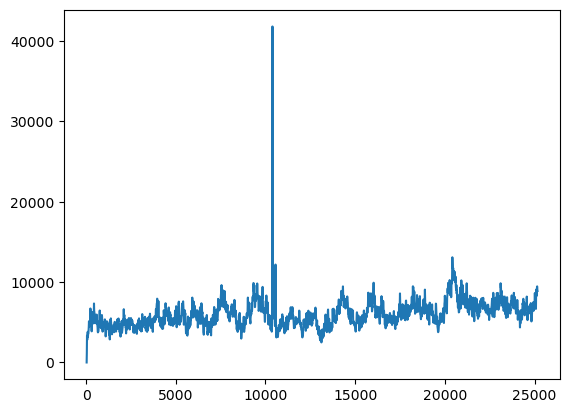

In [27]:
# plt.plot(pd.Series(result).cumsum())
plt.plot(result)